In [1]:
#Importación de funciones de los diferentes archivos
import pandas as pd
import numpy as np

# Guardo todos los datos
df = pd.read_csv('data/clothDataset_33_.csv') 

In [3]:
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import torch
import os, os.path

class ClothDataset(Dataset):
    def __init__(self, csv_data, num_vertices=6):
        """
        Args:
            csv_data (str or filepath): Path to the CSV file or raw CSV string.
            num_vertices (int): Number of vertices per frame.
        """
        # Load the CSV data into a pandas DataFrame
        #if isinstance(csv_data, str) and "frame,x0" in csv_data:
            #self.data = pd.read_csv(io.StringIO(csv_data.strip()))
        #else:
            #self.data = pd.read_csv(csv_data)
        self.data = csv_data
            
        #quick fix para espacios en primera fila
        self.data.columns = self.data.columns.str.strip()
        
        self.num_vertices = num_vertices
        
        # Define the base feature names to extract per vertex
        self.feature_prefixes = ['x', 'y', 'z', 'sdf'] # 'vx', 'vy', 'vz',, 'nx', 'ny', 'nz', 'md', 'u', 'v'

        self.position_prefixes = ['x', 'y', 'z']
        self.output_positions = self.data.filter(regex=r'^[xyz]\d+$')

        # Quitamos primera fila de outputs (no es el output de nada) y ultima fila de input (no tiene output)
        self.output_positions = self.output_positions.iloc[1:]
        self.data = self.data.iloc[:-1]
        

    def __len__(self):
        # The number of items is the number of frames (rows) in the dataset
        return len(self.data)
    
    def num_features(self):
        # Number of columns in a row (pos, vel, sdf, uv per vertex)
        return len(self.feature_prefixes)
    
    def num_vertex(self):
        return self.num_vertices
    
    def _get_frame_output_tensor(self, idx):
         row = self.output_positions.iloc[idx]
         frame_data = []
         for i in range(self.num_vertices):
            vertex_cols = [f"{prefix}{i}" for prefix in self.position_prefixes]
            vertex_features = row[vertex_cols].values.astype(np.float32)
            frame_data.append(vertex_features)

         tensor_data = torch.tensor(np.array(frame_data))

         return tensor_data
    
    def _get_frame_tensor(self, idx):
        row = self.data.iloc[idx]
        frame_data = []

        for i in range(self.num_vertices):
            vertex_cols = [f"{prefix}{i}" for prefix in self.feature_prefixes]
            vertex_features = row[vertex_cols].values.astype(np.float32)
            frame_data.append(vertex_features)

        tensor_data = torch.tensor(np.array(frame_data))

        return tensor_data
        
    def __getitem__(self, idx):
        frame_t = self._get_frame_tensor(idx)
        frame_t1 = self._get_frame_output_tensor(idx) # +1 ya no TODO: Pillar solo las columnas de pos

        return frame_t, frame_t1

# --- Example Usage ---

# (Assuming 'csv_string' is a variable holding your provided data block)
dataset = ClothDataset(df)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

for batch_data, batch_frames in dataloader:
    print(f"Batch Shape: {batch_data.shape}")
    print(batch_data)
    print(batch_frames)
    break



Batch Shape: torch.Size([4, 6, 4])
tensor([[[ 1.9761e-01,  4.0412e-02, -2.2512e-01,  1.2261e+00],
         [ 5.0199e-01, -3.6356e-01,  2.1773e-01,  9.2150e-01],
         [ 5.1442e-01, -3.4621e-01, -2.3282e-01,  8.4763e-01],
         [ 2.2672e-01,  5.3875e-02,  2.2482e-01,  1.2539e+00],
         [ 0.0000e+00,  5.0000e-01, -2.2550e-01,  1.5773e+00],
         [ 0.0000e+00,  5.0000e-01,  2.2550e-01,  1.6202e+00]],

        [[ 2.1294e-02,  3.0336e-04, -2.2539e-01,  2.0096e-01],
         [-2.9003e-02, -4.9915e-01,  2.2248e-01,  2.4246e-01],
         [ 2.5685e-02, -4.9970e-01, -2.2519e-01,  5.6925e-02],
         [ 6.1544e-03, -2.8540e-04,  2.2533e-01,  3.2955e-01],
         [ 0.0000e+00,  5.0000e-01, -2.2550e-01,  5.9143e-01],
         [ 0.0000e+00,  5.0000e-01,  2.2550e-01,  6.7116e-01]],

        [[ 5.2332e-02,  2.7121e-03, -2.2545e-01,  9.5291e-01],
         [ 2.5710e-01, -4.5702e-01,  2.2187e-01,  7.5656e-01],
         [ 2.4068e-01, -4.6049e-01, -2.2874e-01,  7.0048e-01],
         [ 6.392

In [4]:
import torch.nn as nn
import torch.nn.functional as F #acceso rapido a funciones
import torch.utils.data as data #cargar y manejar el training data

class MyModule(nn.Module):

    def __init__(self, num_inputs, num_hidden, num_outputs):
        super().__init__()
        # Some init for my module
        self.linear1 = nn.Linear(num_inputs, num_hidden)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        # Function for performing the calculation of the module.
        
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        #print(x)
        return x

    #backward se hace automaticamente, podriamos definirla tmbn 

#tmbn clases DataSet y DataLoader

# definir modelo, loss function y optimizer
#TODO: buscar dimensiones reales de las neuronas

# nn.Linear in PyTorch is designed to handle 3D tensors seamlessly.  
# When a 3D input tensor (e.g., batch_size, sequence_length, features) is provided,
#  the layer applies the linear transformation only to the last dimension (the features dimension),
#  preserving all other dimensions.


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import numpy as np

# NO SPLITEAMOS LOS DATOS
train_dataset = dataset
test_dataset = dataset

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False) # No need to shuffle test data

# 2. COMPUTE GLOBAL STATS (Only on training data to prevent data leakage)
# Correct Python logic for mean/std
all_inputs = []
all_targets = []

for batch_t, batch_t1 in dataloader:
    # Flatten batch and vertices: (Batch * Vertices, Features)
    all_inputs.append(batch_t.view(-1, 4))
    
    # Do the same for targets (displacements)
    pos_t = batch_t[..., 0:3]
    delta = batch_t1 - pos_t
    all_targets.append(delta.view(-1, 3))

# Combine everything
full_input_tensor = torch.cat(all_inputs, dim=0)
full_target_tensor = torch.cat(all_targets, dim=0)

# Calculate Global Stats
input_mean = full_input_tensor.mean(dim=0)
input_std = full_input_tensor.std(dim=0)
target_mean = full_target_tensor.mean(dim=0)
target_std = full_target_tensor.std(dim=0)

# Save to JSON
norm_data = {
    "mean": input_mean.tolist(),
    "std": input_std.tolist(),
    "target_mean": target_mean.tolist(),
    "target_std": target_std.tolist()
}
# ... save as json ...
import json

with open("cloth_norm_params.json", "w") as f:
    json.dump(norm_data, f)

# 3. SETUP MODEL
model = MyModule(num_inputs=4, num_hidden=64, num_outputs=3)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
print("start training")

# 4. TRAINING & TESTING LOOP
epochs = 50
for epoch in range(epochs):
    
    # --- TRAINING PHASE ---
    model.train() # Set model to training mode
    train_loss = 0.0
    
    for batch_t, batch_t1 in train_loader:
        batch_t = batch_t.float()
        batch_t1 = batch_t1.float()

        # Normalize Input globally
        batch_t_norm = (batch_t - input_mean) / input_std

        # Target is the DISPLACEMENT (Delta), not the absolute position
        positions_t = batch_t[..., 0:3] 
        target_delta = batch_t1 - positions_t
        
        # Note: For best results, target_delta should also be globally normalized, 
        # but we will keep it raw here for easier "Distance Error" calculation later.

        pred_delta = model(batch_t_norm)
        loss = criterion(pred_delta, target_delta)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        train_loss += loss.item()
        
    print(f'Train Epoch {epoch+1:03d}')
        
    avg_train_loss = train_loss / len(train_loader)

    # --- TESTING/VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode
    test_loss = 0.0
    total_distance_error = 0.0
    total_vertices = 0

    all_pred_deltas = []
    all_target_deltas = []

    all_pred_pos = []
    all_target_pos = []
    
    with torch.no_grad(): # Disable gradient calculation for testing (saves memory & speeds up)
        for batch_t, batch_t1 in test_loader:
            batch_t = batch_t.float()
            batch_t1 = batch_t1.float()

            batch_t_norm = (batch_t - input_mean) / input_std
            
            positions_t = batch_t[..., 0:3] 
            target_delta = batch_t1 - positions_t
            
            target_delta_norm = (target_delta - target_mean) / target_std

            pred_delta = model(batch_t_norm)
            loss = criterion(pred_delta, target_delta_norm)
            test_loss += loss.item()

            # --- NEW: Reconstruct the absolute positions ---
            pred_pos = positions_t + pred_delta
            target_pos = batch_t1[..., 0:3] # The true final position

            # Store them
            all_pred_pos.append(pred_pos.cpu().numpy())
            all_target_pos.append(target_pos.cpu().numpy())
            
            # Calculate our "Accuracy" (Mean Distance Error per vertex)
            # Distance = sqrt((dx_pred - dx_true)^2 + (dy_pred - dy_true)^2 + (dz_pred - dz_true)^2)
            distances = torch.norm(pred_delta - target_delta, dim=-1) # Calculates Euclidean distance
            total_distance_error += distances.sum().item()
            total_vertices += distances.numel()

            # --- NEW: Store the data for PCA ---
            # Move tensors to the CPU and convert to NumPy arrays immediately
            all_pred_deltas.append(pred_delta.cpu().numpy())
            all_target_deltas.append(target_delta.cpu().numpy())

            print(f'Epoch {epoch+1:03d} | Test Loss: {test_loss:.6f} | Vertex Error: {total_distance_error:.6f} units')

    avg_test_loss = test_loss / len(test_loader)
    avg_distance_error = total_distance_error / total_vertices

    # Combine into large arrays
    # Shapes will be: (Total_Frames, Vertices, 3)
    preds_pos_np = np.concatenate(all_pred_pos, axis=0)
    targets_pos_np = np.concatenate(all_target_pos, axis=0)

    print(f'Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f} | Avg Vertex Error: {avg_distance_error:.6f} units')


start training
Train Epoch 001
Epoch 001 | Test Loss: 0.897985 | Vertex Error: 7.205257 units
Epoch 001 | Test Loss: 1.744204 | Vertex Error: 17.864567 units
Epoch 001 | Test Loss: 3.992790 | Vertex Error: 26.503269 units
Epoch 001 | Test Loss: 4.666642 | Vertex Error: 35.321179 units
Epoch 001 | Test Loss: 6.418829 | Vertex Error: 42.774021 units
Epoch 001 | Test Loss: 7.145949 | Vertex Error: 52.909954 units
Epoch 001 | Test Loss: 9.741150 | Vertex Error: 61.006585 units
Epoch 001 | Test Loss: 10.449163 | Vertex Error: 69.579157 units
Epoch 001 | Test Loss: 11.724485 | Vertex Error: 77.208970 units
Epoch 001 | Test Loss: 12.396179 | Vertex Error: 86.796856 units
Epoch 001 | Test Loss: 13.611951 | Vertex Error: 95.079503 units
Epoch 001 | Test Loss: 14.176988 | Vertex Error: 104.477010 units
Epoch 001 | Test Loss: 14.576734 | Vertex Error: 111.934747 units
Epoch 001 | Test Loss: 15.044574 | Vertex Error: 120.557519 units
Epoch 001 | Test Loss: 15.954185 | Vertex Error: 128.769256 unit

KeyboardInterrupt: 

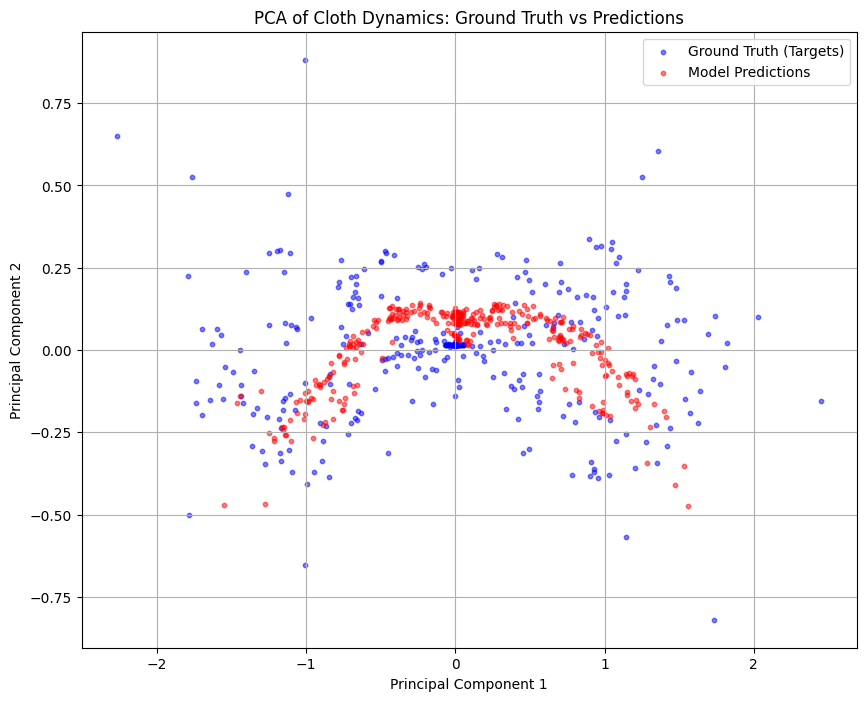

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Combine the collected batches into single large arrays
preds_np = np.concatenate(all_pred_deltas, axis=0)     # Shape: (Total_Frames, Vertices, 3)
targets_np = np.concatenate(all_target_deltas, axis=0) # Shape: (Total_Frames, Vertices, 3)

# 2. Reshape to 2D: (Total_Frames, Vertices * 3)
preds_2d = preds_np.reshape(preds_np.shape[0], -1)
targets_2d = targets_np.reshape(targets_np.shape[0], -1)

# 3. Initialize PCA
pca = PCA(n_components=2) # 2 components for a 2D scatter plot

# CRITICAL: Fit the PCA on the TARGETS (Ground Truth) to define the coordinate space.
# If you fit two separate PCAs, the axes will mean different things and you cannot compare them!
pca.fit(targets_2d)

# Transform both datasets into this shared PCA space
pca_targets = pca.transform(targets_2d)
pca_preds = pca.transform(preds_2d)

# 4. Plot the comparison
plt.figure(figsize=(10, 8))

# Plot ground truth in blue
plt.scatter(pca_targets[:, 0], pca_targets[:, 1], alpha=0.5, label='Ground Truth (Targets)', color='blue', s=10)

# Plot predictions in red
plt.scatter(pca_preds[:, 0], pca_preds[:, 1], alpha=0.5, label='Model Predictions', color='red', s=10)

plt.title('PCA of Cloth Dynamics: Ground Truth vs Predictions')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

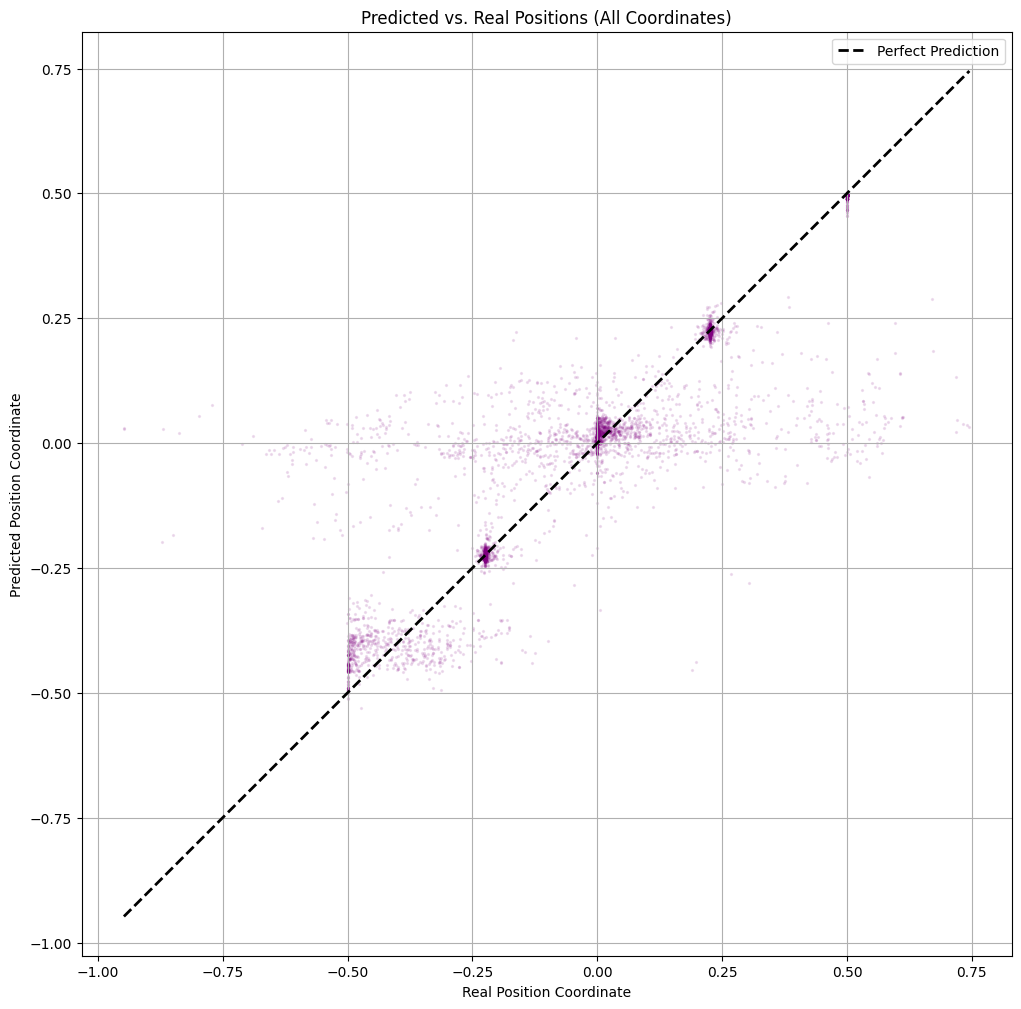

In [8]:
import matplotlib.pyplot as plt

# Flatten the arrays so we just have a massive list of X, Y, and Z coordinates
true_flat = targets_pos_np.reshape(-1)
pred_flat = preds_pos_np.reshape(-1)

plt.figure(figsize=(12, 12))
plt.scatter(true_flat, pred_flat, alpha=0.1, color='purple', s=2)

# Draw the perfect prediction line (y = x)
min_val = min(true_flat.min(), pred_flat.min())
max_val = max(true_flat.max(), pred_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Predicted vs. Real Positions (All Coordinates)')
plt.xlabel('Real Position Coordinate')
plt.ylabel('Predicted Position Coordinate')
plt.legend()
plt.grid(True)
plt.axis('equal') # Keeps the aspect ratio square
plt.show()

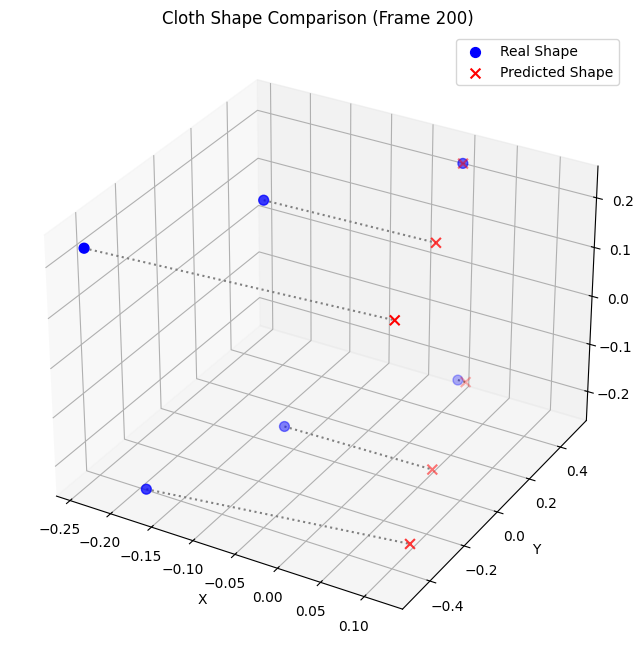

In [11]:
# Choose a random frame from your test set to visualize
frame_idx = 200 # Change this to look at different moments
num_vertices = targets_pos_np.shape[1]

real_frame = targets_pos_np[frame_idx] # Shape: (Vertices, 3)
pred_frame = preds_pos_np[frame_idx]   # Shape: (Vertices, 3)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract X, Y, Z for Real positions
rx, ry, rz = real_frame[:, 0], real_frame[:, 1], real_frame[:, 2]
# Extract X, Y, Z for Predicted positions
px, py, pz = pred_frame[:, 0], pred_frame[:, 1], pred_frame[:, 2]

# Plot the real cloth vertices in Blue
ax.scatter(rx, ry, rz, c='blue', label='Real Shape', s=50, marker='o')

# Plot the predicted cloth vertices in Red
ax.scatter(px, py, pz, c='red', label='Predicted Shape', s=50, marker='x')

# Draw lines connecting the predicted vertex to the real vertex to show the error
for i in range(num_vertices):
    ax.plot([rx[i], px[i]], [ry[i], py[i]], [rz[i], pz[i]], color='gray', linestyle='dotted')

ax.set_title(f'Cloth Shape Comparison (Frame {frame_idx})')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

In [10]:
import torch
import sys
import onnx
import onnxruntime

# 1. Load your trained model (make sure it's in eval mode)
model.eval()

# 2. Create a dummy input strictly enforcing the 3D shape: (Batch=3, Vertices=6, Features=13)
# It doesn't matter what the numbers are, ONNX just needs the shape.
dummy_input = torch.randn(1, 6, 4)

# 3. Export to ONNX
onnx_program = torch.onnx.export(
    model,                      # Your trained PyTorch model
    dummy_input,                # The strictly 3D input tensor
    "cloth_pos_local.onnx",         # Output file name
    export_params=True,         # Store the trained weights
    opset_version=9,            # Sentis handles opset 9-15 well
    input_names=['input'],      # Name the input for Unity
    output_names=['output'],    # Name the output for Unity
)

print("Exported to ONNX with strict 3D shapes!")

Exported to ONNX with strict 3D shapes!
